# Árbol de decisión propio y Random Forest
### Predicción de resultados del fútbol uruguayo — Tarea 1, Aprendizaje Automático

1. **Árbol de decisión propio**, con el hiperparámetro `min_info_gain` (ganancia de información mínima) como único criterio de pre-poda.
2. **Random Forest de scikit-learn**, como modelo de comparación basado en el mismo tipo de atributo (árboles).


In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from src.pipeline import get_train_test_data, preprocessing_pipeline
from src.tree_models import DecisionTreeClassifierCustom

CLASES = ['L', 'E', 'V']  # orden fijo para que las matrices de confusión sean consistentes


## 1. Prueba de humo (sanity check) con dataset de juguete

Antes de usar el dataset real, se valida la lógica del árbol con el clásico dataset "clima / jugar
tenis", donde ya se conoce intuitivamente cómo debería dividir los datos. Esto separa dos tipos de
error posibles: si el árbol falla acá, el problema es de implementación (`_build_tree`,
`_best_split`, cálculo de entropía); si funciona acá pero rinde mal en el dataset real, el problema
está en los datos/atributos disponibles, no en el algoritmo.


In [2]:
# Crear un conjunto de datos de juguete (toy dataset)
data = {
    'Clima': ['Sol', 'Sol', 'Nublado', 'Lluvia', 'Lluvia', 'Lluvia', 'Nublado', 'Sol', 'Sol', 'Lluvia', 'Sol', 'Nublado', 'Nublado', 'Lluvia'],
    'Temperatura': [85, 80, 83, 70, 68, 65, 64, 72, 69, 75, 75, 72, 81, 71],
    'Viento': ['Suave', 'Fuerte', 'Suave', 'Suave', 'Suave', 'Fuerte', 'Fuerte', 'Suave', 'Suave', 'Suave', 'Fuerte', 'Fuerte', 'Suave', 'Fuerte'],
    'Resultado': ['L', 'L', 'E', 'V', 'V', 'L', 'E', 'L', 'V', 'V', 'E', 'E', 'E', 'L']
}
df_toy = pd.DataFrame(data)

# Separar las variables predictoras (X) de la variable objetivo (y)
X_toy = df_toy.drop('Resultado', axis=1)
y_toy = df_toy['Resultado']

# Inicializar y entrenar el modelo de árbol con una ganancia de información mínima baja
tree_model_toy = DecisionTreeClassifierCustom(min_info_gain=0.01)
tree_model_toy.fit(X_toy, y_toy)

# Realizar predicciones y evaluar la precisión del modelo
preds_toy = tree_model_toy.predict(X_toy)
print(f"Predicciones: {preds_toy}")
print(f"Precisión en el entrenamiento: {accuracy_score(y_toy, preds_toy)}")


Predicciones: ['L' 'L' 'E' 'V' 'V' 'L' 'E' 'L' 'V' 'V' 'E' 'E' 'E' 'L']
Precisión en el entrenamiento: 1.0


**Resultado esperado**: accuracy de 1.0 sobre el propio conjunto de entrenamiento — con
`min_info_gain=0.01` y solo 14 ejemplos, el árbol tiene margen de sobra para memorizar
perfectamente este dataset chico. Esto confirma que `fit()` / `predict()` / `_build_tree()`
funcionan correctamente, pero **no dice nada todavía sobre generalización** — para eso está el
dataset real, con partición temporal train/test (secciones siguientes).


## 2. Carga de datos y preprocesamiento (pipeline del Rol 1)

Se reutiliza `get_train_test_data` (partición temporal: train hasta 2023 inclusive, test
2024-2025) y `preprocessing_pipeline`, que aplica en orden: limpieza de columnas irrelevantes,
`TeamFormTransformer` (tasa de victoria reciente de cada equipo en los últimos 10 años,
`home_form`/`away_form`), extracción de año/mes, y one-hot encoding de `home`/`away`.

**Decisión de equipo — codificación one-hot vs. categórica cruda**: el árbol propio soporta
splits categóricos nativos (por subconjunto de valores) para atributos de texto, lo que en teoría
permitiría usar `home`/`away` como texto plano en vez de one-hot. Sin embargo, se decidió usar la
**misma versión one-hot que el Random Forest** (que sí la necesita, al no soportar texto
directamente), para que ambos modelos compartan exactamente el mismo conjunto de atributos y la
comparación final entre ellos sea justa (ver sección 6).

**Nota de rendimiento**: `home_form`/`away_form` son tasas continuas; se redondean a 2 decimales
dentro de `TeamFormTransformer` para no disparar el costo de `_best_split`, que prueba cada valor
único como candidato de corte (con valores sin redondear, casi cada partido tendría un valor
distinto, haciendo la búsqueda de umbral extremadamente lenta).


In [3]:
print("Cargando y procesando los datos...")
X_train, y_train, X_test, y_test = get_train_test_data(filepath='../data/raw/futbol_uruguayo.csv')

# TeamFormTransformer necesita 'y' para construir el historial de victorias -> pasar y_train acá
X_train_processed = preprocessing_pipeline.fit_transform(X_train, y_train)
X_test_processed = preprocessing_pipeline.transform(X_test)
nomi_colonne = preprocessing_pipeline.named_steps['encoder'].get_feature_names_out()

X_train_visibile = pd.DataFrame(X_train_processed, columns=nomi_colonne)
X_test_visibile = pd.DataFrame(X_test_processed, columns=nomi_colonne)

print(f"Atributos finales ({X_train_visibile.shape[1]}): {list(X_train_visibile.columns[-6:])} (+ equipos one-hot)")


Cargando y procesando los datos...
Atributos finales (80): ['teams_encoder__away_Torque FC', 'teams_encoder__away_Villa Teresa', 'remainder__home_form', 'remainder__away_form', 'remainder__year', 'remainder__month'] (+ equipos one-hot)


## 3. Búsqueda del hiperparámetro `min_info_gain` (árbol propio)

**Teoría**: la construcción del árbol elige, en cada nodo, el atributo que maximiza la ganancia de
información respecto a la entropía del nodo padre:

$$\text{Entropía}(S) = -\sum_{c \in \{L,E,V\}} p_c \log_2 p_c \qquad\qquad
\text{Ganancia}(S, A) = \text{Entropía}(S) - \sum_{v \in \text{valores}(A)} \frac{|S_v|}{|S|}\,\text{Entropía}(S_v)$$

`min_info_gain` es el **único** mecanismo de regularización del árbol (no hay límite de
profundidad ni mínimo de ejemplos por hoja): en cada nodo, si la mejor ganancia entre todos los
atributos candidatos no supera este umbral, la recursión se detiene y el nodo se convierte en hoja
(clase mayoritaria del subconjunto). Valores bajos favorecen árboles profundos (riesgo de
sobreajuste); valores altos detienen la construcción antes (riesgo de subajuste).

Se usa `TimeSeriesSplit` en vez de un k-fold aleatorio: al ser datos cronológicos, un k-fold
clásico dejaría que el modelo "vea" partidos futuros para predecir partidos pasados. Se optimiza
macro-F1, coherente con la métrica pedida por la letra para la comparación final entre modelos.


Buscando los mejores hiperparámetros para el Árbol Personalizado...
Búsqueda terminada! Mejor min_info_gain encontrado: 0.0
Realizando predicciones para 2024-2025 con el MEJOR modelo...

Resultados del Mejor Árbol de Decisión:
Precisión (Accuracy): 0.3475
Macro-F1 (Métrica Principal): 0.3410

Matriz de Confusión:


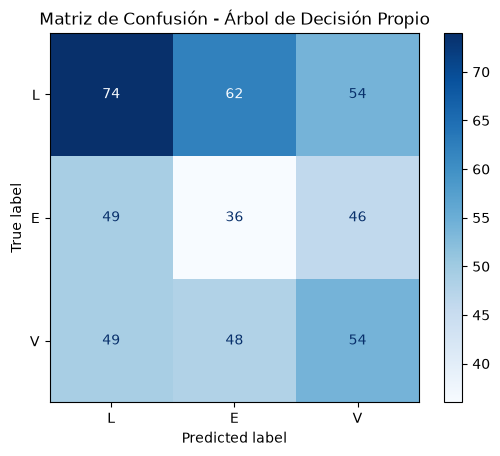

In [4]:
print("Buscando los mejores hiperparámetros para el Árbol Personalizado...")

tscv = TimeSeriesSplit(n_splits=5)

param_grid_arvore = {
    'min_info_gain': [0.0, 0.0005, 0.001, 0.005, 0.01, 0.05]
}

grid_arvore = GridSearchCV(
    estimator=DecisionTreeClassifierCustom(),
    param_grid=param_grid_arvore,
    cv=tscv,
    scoring='f1_macro',
    return_train_score=True
)

grid_arvore.fit(X_train_visibile, y_train)

mejor_ganancia = grid_arvore.best_params_['min_info_gain']
print(f"Búsqueda terminada! Mejor min_info_gain encontrado: {mejor_ganancia}")

print("Realizando predicciones para 2024-2025 con el MEJOR modelo...")
arvore_mejor_modelo = grid_arvore.best_estimator_
preds_arvore = arvore_mejor_modelo.predict(X_test_visibile)

macro_f1 = f1_score(y_test, preds_arvore, average='macro')
acuracia = accuracy_score(y_test, preds_arvore)

print(f"\nResultados del Mejor Árbol de Decisión:")
print(f"Precisión (Accuracy): {acuracia:.4f}")
print(f"Macro-F1 (Métrica Principal): {macro_f1:.4f}")
print("\nMatriz de Confusión:")

cm_arvore = confusion_matrix(y_test, preds_arvore, labels=CLASES)

disp_arvore = ConfusionMatrixDisplay(confusion_matrix=cm_arvore, display_labels=CLASES)
disp_arvore.plot(cmap=plt.cm.Blues)

plt.title("Matriz de Confusión - Árbol de Decisión Propio")
plt.show()


**Resultado obtenido**: `min_info_gain=0.0` fue elegido como mejor en la búsqueda, con
macro-F1 ≈ **0.341** y accuracy ≈ **0.348** sobre el conjunto de test (2024-2025) — apenas por
encima del nivel de acierto aleatorio (~0.33 con 3 clases). Que el valor de regularización más
bajo posible haya "ganado" es una señal de alerta que se investiga en la sección siguiente.


## 4. Diagnóstico: ¿por qué `min_info_gain=0.0` es siempre el mejor?

Dos hipótesis se plantearon durante el desarrollo:

**Hipótesis A — sesgo de alta cardinalidad.** El criterio de ganancia de información favorece a
los atributos con muchos valores posibles: un split de `home`/`away` en ~40 ramas (una por equipo)
casi siempre "parece" ganar más información en el training que un split binario, aunque esa
división no generalice — es un sesgo conocido del criterio ID3 puro (el C4.5 lo corrige
normalizando por *gain ratio*, algo que esta implementación no incluye por no ser requerido por la
letra). Bajo esta hipótesis, quitar `home`/`away` debería reducir el sobreajuste.

**Hipótesis B — limitación estructural del criterio de parada.** Usar únicamente `min_info_gain`
(sin profundidad máxima ni mínimo de ejemplos por hoja) permite que el árbol siga dividiendo hasta
nodos con muy pocos ejemplos. La entropía calculada sobre pocos ejemplos es inestable: un split que
separa perfectamente 3 o 4 ejemplos residuales puede dar una ganancia de información alta por puro
azar, superando incluso umbrales relativamente altos de `min_info_gain`.

Se prueban ambas con dos chequeos:
1. Accuracy del mejor árbol sobre su **propio** conjunto de entrenamiento (evidencia directa de
   sobreajuste).
2. Repetir la búsqueda de `min_info_gain`, con una grilla más amplia, **quitando** `home`/`away`
   (si la Hipótesis A fuera la causa principal, el resultado debería mejorar notablemente).


In [5]:
mejor_ganancia = grid_arvore.best_params_['min_info_gain'] if ('grid_arvore' in locals() and hasattr(grid_arvore, 'best_params_')) else (getattr(arvore_mejor_modelo, 'min_info_gain', 0.0) if 'arvore_mejor_modelo' in locals() else 0.0)
acc_entrenamiento = accuracy_score(y_train, arvore_mejor_modelo.predict(X_train_visibile))
print(f"Precisión en el entrenamiento (mejor arbol, min_info_gain={mejor_ganancia}): {acc_entrenamiento:.4f}")


Precisión en el entrenamiento (mejor arbol, min_info_gain=0.0): 0.9994


In [6]:
columnas_equipo = [c for c in X_train_visibile.columns if c.startswith('teams_encoder__')]
X_train_sin_equipo = X_train_visibile.drop(columns=columnas_equipo)
X_test_sin_equipo = X_test_visibile.drop(columns=columnas_equipo)

param_grid_arbol_ampliada = {'min_info_gain': [0.0, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5]}

grid_arbol_v2 = GridSearchCV(
    estimator=DecisionTreeClassifierCustom(),
    param_grid=param_grid_arbol_ampliada,
    cv=tscv,
    scoring='f1_macro',
    return_train_score=True
)
grid_arbol_v2.fit(X_train_sin_equipo, y_train)

mejor_v2 = grid_arbol_v2.best_estimator_
preds_v2 = mejor_v2.predict(X_test_sin_equipo)

print(f"Mejor min_info_gain (sin home/away, grilla ampliada): {grid_arbol_v2.best_params_['min_info_gain']}")
print(f"Macro-F1 (test): {f1_score(y_test, preds_v2, average='macro'):.4f}")
print(f"Precisión en el entrenamiento: {accuracy_score(y_train, mejor_v2.predict(X_train_sin_equipo)):.4f}")

Mejor min_info_gain (sin home/away, grilla ampliada): 0.0
Macro-F1 (test): 0.3367
Precisión en el entrenamiento: 0.9789


**Resultados obtenidos**:

| Chequeo | `min_info_gain` elegido | Macro-F1 (test) | Accuracy (train) |
|---|---|---|---|
| Con `home`/`away`, grilla original | 0.0 | 0.341 | **0.9994** |
| Sin `home`/`away`, grilla ampliada (hasta 0.5) | 0.0 | 0.337 (≈ igual) | **0.9789** |

**Hipótesis A descartada**: quitar `home`/`away` no cambió el resultado de forma relevante (0.341
→ 0.337), y `min_info_gain=0.0` siguió siendo el mejor incluso probando valores mucho más altos.
Si el sesgo de alta cardinalidad de esas dos columnas fuera la causa principal, se hubiera
esperado una mejora notable al eliminarlas.

**Hipótesis B confirmada como la explicación más consistente**: con accuracy de entrenamiento
≈0.98-0.99 en ambos escenarios, el árbol memoriza casi por completo el conjunto de entrenamiento
sin importar qué atributos recibe — es la firma característica de sobreajuste estructural, no un
problema de qué atributo en particular se usa. **Limitación que queda documentada para el
informe**: usar solo `min_info_gain` como criterio de parada, sin profundidad máxima ni mínimo de
ejemplos por hoja, no alcanza para frenar el crecimiento del árbol en nodos con pocos ejemplos.


## 5. Random Forest de scikit-learn

Se entrena como modelo de comparación basado en el mismo tipo de atributo (árboles), sobre el
mismo conjunto de atributos (`X_train_visibile`) que el árbol propio, para que la comparación de
la sección 6 sea justa. Mismo esquema de validación temporal y misma métrica de optimización.


Buscando los mejores hiperparametros para el Random Forest...
Busqueda terminada. Mejores parametros encontrados: {'max_depth': None, 'n_estimators': 200}
Realizando predicciones para 2024-2025 con el mejor Random Forest...

Resultados del Mejor Random Forest:
Precision (Accuracy): 0.4195
Macro-F1 (Métrica Principal): 0.3896

Matriz de Confusión:


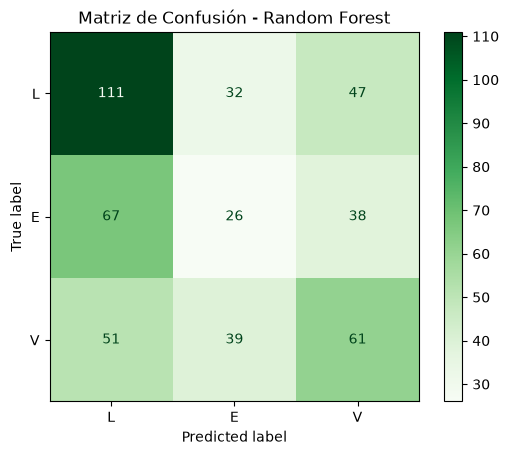


Reporte detallado por clase (Precisión, Recall, F1):
              precision    recall  f1-score   support

           L       0.48      0.58      0.53       190
           E       0.27      0.20      0.23       131
           V       0.42      0.40      0.41       151

    accuracy                           0.42       472
   macro avg       0.39      0.40      0.39       472
weighted avg       0.40      0.42      0.41       472



In [7]:
print("Buscando los mejores hiperparametros para el Random Forest...")

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=tscv,
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True
)

grid_rf.fit(X_train_visibile, y_train)

mejores_params = grid_rf.best_params_
print(f"Busqueda terminada. Mejores parametros encontrados: {mejores_params}")

print("Realizando predicciones para 2024-2025 con el mejor Random Forest...")
mejor_rf = grid_rf.best_estimator_
preds_rf = mejor_rf.predict(X_test_visibile)

macro_f1_rf = f1_score(y_test, preds_rf, average='macro')
acuracia_rf = accuracy_score(y_test, preds_rf)

print("\nResultados del Mejor Random Forest:")
print(f"Precision (Accuracy): {acuracia_rf:.4f}")
print(f"Macro-F1 (Métrica Principal): {macro_f1_rf:.4f}")

print("\nMatriz de Confusión:")
cm_rf = confusion_matrix(y_test, preds_rf, labels=CLASES)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=CLASES)
disp_rf.plot(cmap=plt.cm.Greens) 

plt.title("Matriz de Confusión - Random Forest")
plt.show()

print("\nReporte detallado por clase (Precisión, Recall, F1):")
print(classification_report(y_test, preds_rf, labels=CLASES))


**Resultado obtenido**: macro-F1 ≈ **0.390**, accuracy ≈ **0.420** — algo mejor que el árbol
propio (0.341 / 0.348), como es esperable: el *bagging* del Random Forest tolera árboles
individuales sobreajustados porque la votación conjunta reduce la varianza, algo que un único
árbol no tiene forma de compensar.


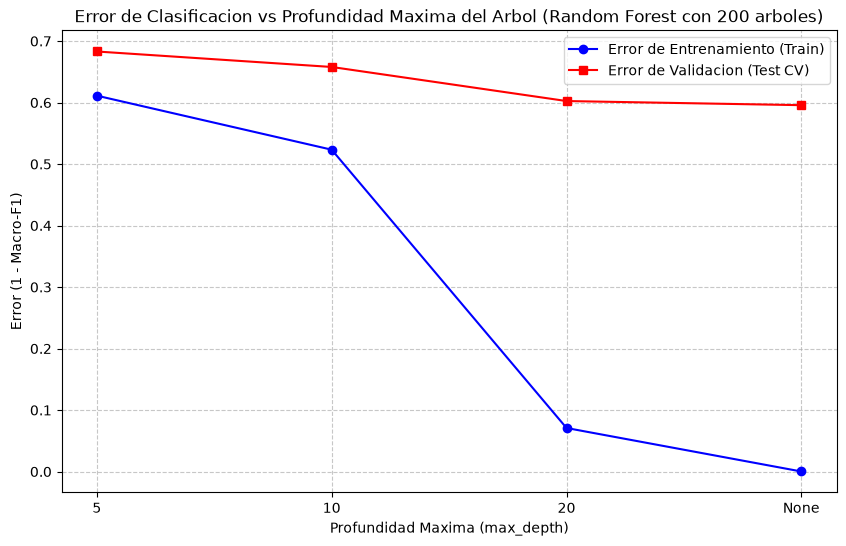

In [8]:
resultados = grid_rf.cv_results_

indices_optimos = [i for i, params in enumerate(resultados['params']) if params['n_estimators'] == 200]
profundidades = [str(resultados['params'][i]['max_depth']) for i in indices_optimos]

error_entrenamiento = 1 - resultados['mean_train_score'][indices_optimos]
error_validacion = 1 - resultados['mean_test_score'][indices_optimos]

plt.figure(figsize=(10, 6))
plt.plot(profundidades, error_entrenamiento, marker='o', label='Error de Entrenamiento (Train)', color='blue')
plt.plot(profundidades, error_validacion, marker='s', label='Error de Validacion (Test CV)', color='red')

plt.title('Error de Clasificacion vs Profundidad Maxima del Arbol (Random Forest con 200 arboles)')
plt.xlabel('Profundidad Maxima (max_depth)')
plt.ylabel('Error (1 - Macro-F1)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()


**Lectura del gráfico**: el error de entrenamiento cae a ~0 con `max_depth=None`, mientras el
error de validación sigue mejorando levemente — a diferencia del árbol único (sección 4), este gap
grande **no es alarmante** en un Random Forest: es el comportamiento esperado del bagging, y por
eso no se interpreta como sobreajuste de la misma forma que en un árbol individual.


## 6. Comparación entre el árbol propio y Random Forest

| Modelo | Accuracy (test) | Macro-F1 (test) | Accuracy (train) |
|---|---|---|---|
| Árbol propio (`min_info_gain=0.0`) | 0.348 | 0.341 | 0.999 |
| Random Forest (`max_depth=None`, `n_estimators=200`) | 0.420 | 0.390 | ~1.00 |

Ambos modelos superan apenas el nivel de acierto aleatorio (~0.33), y el Random Forest rinde algo
mejor que el árbol propio, consistente con la ventaja esperada del bagging frente a un único árbol
sin límite de profundidad.

**Pendiente antes de sacar conclusiones definitivas**: comparar ambos contra el clasificador
baseline (`ClasificadorBase10Anios`, Rol 1) sobre este mismo conjunto de test. Si el baseline
obtiene un macro-F1 cercano a estos valores, la conclusión relevante para el informe pasa a ser
"ningún modelo complejo supera una heurística simple", en vez de "cuál modelo es mejor".


## 7. Análisis cualitativo

Con base en la matriz de confusión del árbol propio (sección 3) y el diagnóstico de la sección 4:

- El árbol memoriza casi por completo el conjunto de entrenamiento (accuracy ≈0.999) pero
  generaliza apenas por encima del azar — la brecha train/test es la evidencia más clara de
  sobreajuste, y se debe a que `min_info_gain` es el único freno disponible, sin control sobre la
  profundidad ni el tamaño mínimo de las hojas.
- Se descartó como causa principal el sesgo de alta cardinalidad de `home`/`away`: quitarlos no
  cambió el resultado de forma relevante (sección 4), lo que indica que el límite está en la
  cantidad de señal real disponible en los atributos (`home_form`, `away_form`, año, mes), no en
  cuáles de ellos se incluyen.
- El patrón de errores más notorio en la matriz de confusión es la sobre-predicción de `L`
  (victoria del local) — consistente con la ventaja de local documentada en el fútbol en general —
  a costa de `E` (empate), la clase más difícil de anticipar con los atributos disponibles.
- Próximo paso natural: agregar atributos que capturen la diferencia de nivel *entre los dos
  equipos de un partido puntual* (por ejemplo, diferencia `home_form - away_form`, o historial de
  enfrentamientos directos), en vez de solo la forma de cada equipo por separado.
